In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from src.config import *

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import DEV_SNAPSHOTS
from src.graph.manager import TemporalGraphManager
from src.community.detector import CommunityDetector
from src.community.matcher import CommunityMatcher
from src.community.tracker import CommunityTracker
from src.community.timeline import CommunityTimeline

In [4]:
manager = TemporalGraphManager()

manager.build_all(DEV_SNAPSHOTS)

2026-07-20 14:33:44,360 | INFO | Loading processed dataset...
2026-07-20 14:33:56,594 | INFO | Dataset loaded successfully.
2026-07-20 14:33:56,596 | INFO | Building temporal graphs...
2026-07-20 14:33:56,597 | INFO | Building graph for timestep 20
2026-07-20 14:33:56,780 | INFO | Graph built successfully | Nodes: 900 | Edges: 613
2026-07-20 14:33:56,781 | INFO | Snapshot 20 validated.
2026-07-20 14:33:56,831 | INFO | Detected 327 communities.
2026-07-20 14:33:56,833 | INFO | Building graph for timestep 21
2026-07-20 14:33:56,970 | INFO | Graph built successfully | Nodes: 641 | Edges: 518
2026-07-20 14:33:56,971 | INFO | Snapshot 21 validated.
2026-07-20 14:33:57,001 | INFO | Detected 238 communities.
2026-07-20 14:33:57,002 | INFO | Building graph for timestep 22
2026-07-20 14:33:57,361 | INFO | Graph built successfully | Nodes: 1763 | Edges: 1537
2026-07-20 14:33:57,362 | INFO | Snapshot 22 validated.
2026-07-20 14:33:57,461 | INFO | Detected 536 communities.
2026-07-20 14:33:57,463 

In [5]:
for graph in manager.graphs.values():

    CommunityDetector.detect(graph)

print("Community detection complete.")

2026-07-20 14:33:58,157 | INFO | Detected 327 communities.
2026-07-20 14:33:58,188 | INFO | Detected 238 communities.
2026-07-20 14:33:58,291 | INFO | Detected 536 communities.
2026-07-20 14:33:58,353 | INFO | Detected 210 communities.
2026-07-20 14:33:58,424 | INFO | Detected 254 communities.


Community detection complete.


In [6]:
tracker = CommunityTracker()

tracker.track(manager.graphs)

print(f"Tracked {len(tracker.community_map)} community instances.")

Tracked 1565 community instances.


In [7]:
timeline = CommunityTimeline()

timeline.build(
    tracker,
    manager.graphs,
)

print(f"Built {len(timeline.timelines)} timelines.")

2026-07-20 14:34:22,657 | INFO | Built 1037 community timelines.


Built 1037 timelines.


In [8]:
graph = manager.get_snapshot(20)

communities = CommunityMatcher.get_communities(graph)

sizes = sorted(
    [len(nodes) for nodes in communities.values()],
    reverse=True,
)

print(f"Number of communities : {len(communities)}")
print(f"Largest community     : {max(sizes)}")
print(f"Smallest community    : {min(sizes)}")
print(f"Average size          : {sum(sizes)/len(sizes):.2f}")

Number of communities : 327
Largest community     : 39
Smallest community    : 1
Average size          : 2.75


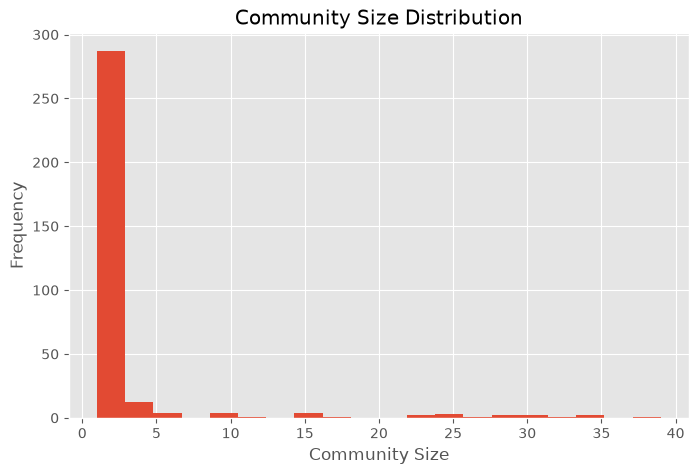

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    sizes,
    bins=20
)

plt.title("Community Size Distribution")

plt.xlabel("Community Size")

plt.ylabel("Frequency")

plt.show()

In [10]:
graph20 = manager.get_snapshot(20)

graph21 = manager.get_snapshot(21)

matches = CommunityMatcher.match(
    graph20,
    graph21,
)

print(f"Matches Found: {len(matches)}")

matches

Matches Found: 327


{0: {'community': 177, 'score': np.float64(0.7488)},
 1: {'community': 17, 'score': np.float64(0.6983)},
 2: {'community': 0, 'score': np.float64(0.7473)},
 3: {'community': 56, 'score': np.float64(0.7487)},
 4: {'community': 11, 'score': np.float64(0.7327)},
 5: {'community': 22, 'score': np.float64(0.8813)},
 15: {'community': 11, 'score': np.float64(0.7182)},
 7: {'community': 12, 'score': np.float64(0.6948)},
 8: {'community': 87, 'score': np.float64(0.7044)},
 9: {'community': 92, 'score': np.float64(0.7751)},
 10: {'community': 0, 'score': np.float64(0.6797)},
 11: {'community': 18, 'score': np.float64(0.8067)},
 12: {'community': 144, 'score': np.float64(0.8475)},
 13: {'community': 89, 'score': np.float64(0.7713)},
 14: {'community': 113, 'score': np.float64(0.8587)},
 16: {'community': 9, 'score': np.float64(0.8145)},
 17: {'community': 86, 'score': np.float64(0.7763)},
 18: {'community': 135, 'score': np.float64(0.9785)},
 19: {'community': 87, 'score': np.float64(0.8334)},
 

In [11]:
list(tracker.community_map.items())[:10]

[((20, 0),
  {'pcid': 0,
   'previous_community': None,
   'current_community': 0,
   'score': 1.0}),
 ((20, 1),
  {'pcid': 1,
   'previous_community': None,
   'current_community': 1,
   'score': 1.0}),
 ((20, 2),
  {'pcid': 2,
   'previous_community': None,
   'current_community': 2,
   'score': 1.0}),
 ((20, 3),
  {'pcid': 3,
   'previous_community': None,
   'current_community': 3,
   'score': 1.0}),
 ((20, 4),
  {'pcid': 4,
   'previous_community': None,
   'current_community': 4,
   'score': 1.0}),
 ((20, 5),
  {'pcid': 5,
   'previous_community': None,
   'current_community': 5,
   'score': 1.0}),
 ((20, 15),
  {'pcid': 6,
   'previous_community': None,
   'current_community': 15,
   'score': 1.0}),
 ((20, 7),
  {'pcid': 7,
   'previous_community': None,
   'current_community': 7,
   'score': 1.0}),
 ((20, 8),
  {'pcid': 8,
   'previous_community': None,
   'current_community': 8,
   'score': 1.0}),
 ((20, 9),
  {'pcid': 9,
   'previous_community': None,
   'current_community': 

In [12]:
pcid = 0

timeline.get_timeline(pcid)

[{'timestep': 20,
  'graph': <networkx.classes.digraph.DiGraph at 0x115c73380>,
  'community': 0,
  'previous_community': None,
  'score': 1.0}]

In [13]:
summary = pd.DataFrame(
    timeline.summarize()
)

summary.head()

,pcid,birth,death,lifetime,persistence,snapshots
0,0,20,20,1,1,1
1,1,20,20,1,1,1
2,2,20,20,1,1,1
3,3,20,20,1,1,1
4,4,20,20,1,1,1


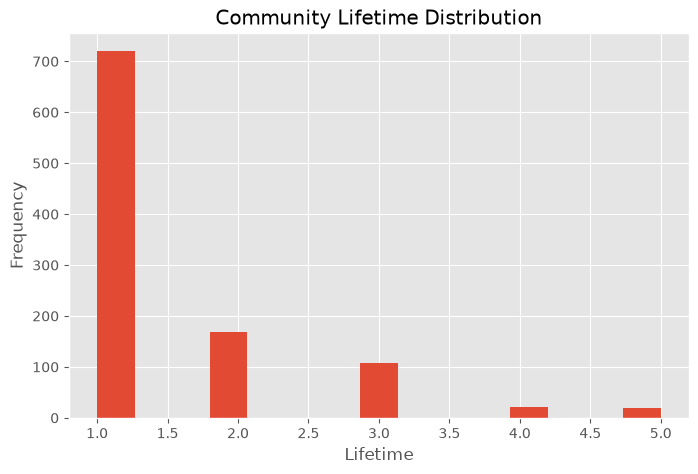

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    summary["lifetime"],
    bins=15
)

plt.title("Community Lifetime Distribution")

plt.xlabel("Lifetime")

plt.ylabel("Frequency")

plt.show()

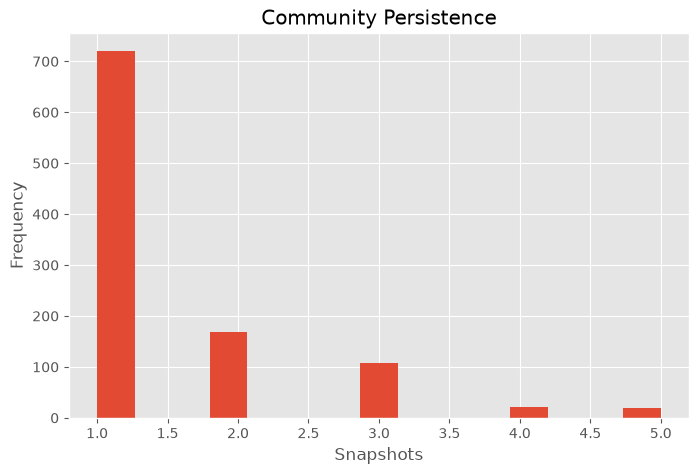

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    summary["persistence"],
    bins=15
)

plt.title("Community Persistence")

plt.xlabel("Snapshots")

plt.ylabel("Frequency")

plt.show()

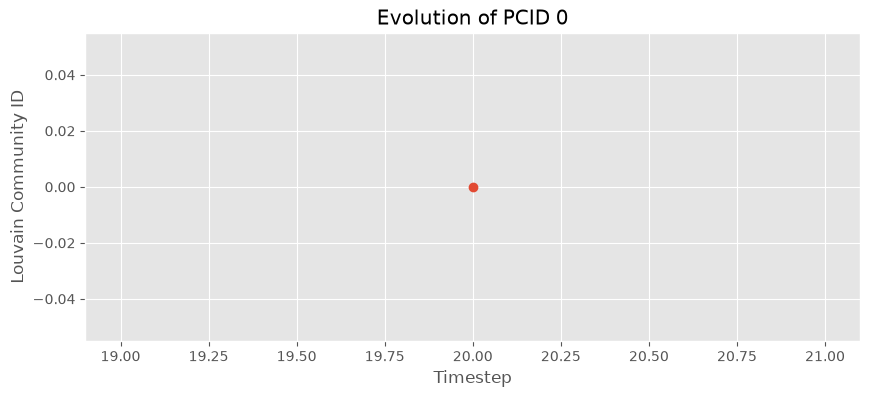

In [16]:
pcid = 0

records = timeline.get_timeline(pcid)

times = [
    r["timestep"]
    for r in records
]

communities = [
    r["community"]
    for r in records
]

plt.figure(figsize=(10,4))

plt.plot(
    times,
    communities,
    marker="o"
)

plt.title(f"Evolution of PCID {pcid}")

plt.xlabel("Timestep")

plt.ylabel("Louvain Community ID")

plt.grid(True)

plt.show()

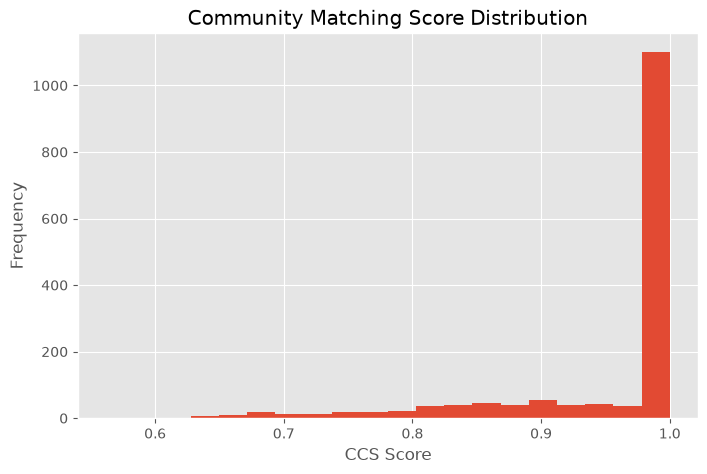

In [17]:
scores = []

for metadata in tracker.community_map.values():

    scores.append(
        metadata["score"]
    )

plt.figure(figsize=(8,5))

plt.hist(
    scores,
    bins=20
)

plt.title("Community Matching Score Distribution")

plt.xlabel("CCS Score")

plt.ylabel("Frequency")

plt.show()

In [18]:
summary.sort_values(
    "lifetime",
    ascending=False
).head(10)

,pcid,birth,death,lifetime,persistence,snapshots
314,314,20,24,5,5,5
180,180,20,24,5,5,5
74,74,20,24,5,5,5
84,84,20,24,5,5,5
85,85,20,24,5,5,5
93,93,20,24,5,5,5
121,121,20,24,5,5,5
137,137,20,24,5,5,5
161,161,20,24,5,5,5
191,191,20,24,5,5,5


In [19]:
summary.sort_values(
    "persistence",
    ascending=False
).head(10)

,pcid,birth,death,lifetime,persistence,snapshots
314,314,20,24,5,5,5
180,180,20,24,5,5,5
74,74,20,24,5,5,5
84,84,20,24,5,5,5
85,85,20,24,5,5,5
93,93,20,24,5,5,5
121,121,20,24,5,5,5
137,137,20,24,5,5,5
161,161,20,24,5,5,5
191,191,20,24,5,5,5


In [20]:
print(f"Snapshots               : {len(manager.graphs)}")
print(f"Community Instances     : {len(tracker.community_map)}")
print(f"Persistent Communities  : {len(timeline.timelines)}")

Snapshots               : 5
Community Instances     : 1565
Persistent Communities  : 1037


Initially, the Community Continuity Score (CCS) matched communities primarily using member overlap (Jaccard similarity), combined with fraud ratio, density, and average degree. This approach assumes that the same nodes persist across consecutive snapshots. However, in the Elliptic Bitcoin Dataset, each node represents a transaction, and transactions exist only in a single timestep. As a result, the member overlap between communities in consecutive snapshots is almost always zero, causing the tracker to incorrectly treat every community as a newly born community and resulting in community lifetimes of one snapshot. To address this, we redesigned CCS to be behavior-aware rather than identity-aware. Instead of comparing transaction IDs, the new matcher compares community feature centroids (using the transaction feature vectors), fraud ratio similarity, density similarity, average degree similarity, and community size similarity. This allows EvoFinGraph to track communities based on similar behavioral and structural characteristics, making the tracking methodology suitable for temporal transaction graphs where node identities naturally change over time.

So we changed the matcher.py and rerunning this notebook

DAY 4 TEST FOR FEATURES.PY PART 1

In [21]:
from src.community.snapshot_features import SnapshotFeatureExtractor
from src.community.matcher import CommunityMatcher

graph = manager.get_snapshot(20)

extractor = SnapshotFeatureExtractor(graph)

communities = CommunityMatcher.get_communities(graph)

community = list(communities.keys())[0]

features = extractor.extract(community)

for key, value in features.items():

    if isinstance(value, np.ndarray):

        print(f"{key}: {value.shape}")

    else:

        print(f"{key}: {value}")

community: 0
timestep: 20
size: 1
density: 0.0
average_degree: 0.0
average_clustering: 0.0
fraud_ratio: 0.0
feature_centroid: (165,)
feature_variance: (165,)
centroid_norm: 14.435206775823843
variance_mean: 0.0
variance_std: 0.0


In [22]:
communities = CommunityMatcher.get_communities(graph)

for cid, nodes in communities.items():

    print(
        cid,
        len(nodes)
    )

0 1
1 5
2 15
3 39
4 34
5 1
15 33
7 23
8 15
9 1
10 25
11 24
12 9
13 3
14 24
16 1
17 29
18 1
19 23
20 1
21 34
22 16
23 26
24 30
25 2
26 9
27 1
28 17
29 28
30 1
31 1
32 1
91 30
34 2
35 2
36 1
37 1
38 1
39 1
40 5
41 1
43 1
44 1
45 10
46 6
47 2
48 4
49 1
50 2
51 1
52 1
53 1
54 1
55 1
56 1
57 11
58 2
59 4
60 1
61 1
62 3
63 1
65 1
66 1
67 1
68 2
69 3
70 1
71 1
72 1
73 1
75 1
76 1
77 1
78 3
79 1
80 1
81 1
82 1
83 1
84 10
85 1
86 15
87 1
88 1
89 1
90 1
92 1
93 1
94 1
95 2
96 1
97 4
98 1
99 1
100 1
101 1
102 1
103 1
104 2
105 1
106 2
107 1
108 3
109 1
110 1
111 1
112 1
113 1
114 1
115 1
116 2
117 1
118 1
119 1
120 1
121 1
122 2
123 1
124 1
125 1
126 3
127 1
128 1
129 1
130 1
131 1
132 1
133 1
134 1
135 1
136 1
137 1
138 1
139 1
140 1
141 1
142 3
143 1
144 1
145 1
146 1
147 1
148 1
149 1
150 1
151 1
152 1
153 2
154 1
155 1
156 1
157 1
158 1
159 2
160 2
161 3
162 1
163 1
164 1
165 1
166 5
167 1
168 1
169 1
170 1
171 1
172 1
173 1
174 2
175 1
176 1
177 1
178 1
179 1
180 1
181 1
182 1
183 1
184 1
18

In [23]:
largest = max(

    communities,

    key=lambda c: len(
        communities[c]
    )

)

print(largest)

print(len(communities[largest]))

3
39


In [24]:
extractor = SnapshotFeatureExtractor(graph)

features = extractor.extract(
    largest
)

for key, value in features.items():

    if isinstance(value, np.ndarray):

        print(key, value.shape)

    else:

        print(key, value)

community 3
timestep 20
size 39
density 0.02631578947368421
average_degree 2.282051282051282
average_clustering 0.007692307692307692
fraud_ratio 0.02564102564102564
feature_centroid (165,)
feature_variance (165,)
centroid_norm 5.03411999715652
variance_mean 1.0765697263197815
variance_std 1.8345778420904482


In [25]:
import importlib
import src.community.snapshot_features

importlib.reload(src.community.snapshot_features)

from src.community.snapshot_features import SnapshotFeatureExtractor

In [26]:
from src.community.snapshot_features import SnapshotFeatureExtractor

graph = manager.get_snapshot(20)

extractor = SnapshotFeatureExtractor(graph)

df = extractor.extract_all()

df.head()

,community,timestep,size,density,average_degree,average_clustering,fraud_ratio,feature_centroid,feature_variance,centroid_norm,variance_mean,variance_std
0,0,20,1,0.000000,0.000000,0.000000,0.000000,"[-0.1720398355415328, 0.9335656498221396, -0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",14.435207,0.000000,0.000000
1,1,20,5,0.200000,1.600000,0.000000,0.000000,"[-0.17275198141864478, -0.15466680420479836, 0...","[1.0922981850374304e-08, 0.0003794232096392534...",5.441680,0.642285,1.404417
2,2,20,15,0.066667,1.933333,0.000000,0.000000,"[-0.14346918620267252, 0.006982260812369858, 0...","[0.002452809134298572, 0.042840540983722905, 1...",6.236225,2.172669,6.015097
3,3,20,39,0.026316,2.282051,0.007692,0.025641,"[0.36271990875786503, -0.1031480988483294, 0.6...","[0.9800192743286337, 0.011834065458037939, 0.4...",5.034120,1.076570,1.834578
4,4,20,34,0.030303,2.088235,0.019716,0.058824,"[-0.1495745946871617, 0.021873653383865415, -0...","[0.002506108784602569, 0.649177386756054, 1.05...",3.184824,0.831587,1.180674


PART 2 COMMUNITY_FEATURES TESTING

In [27]:
from src.community.community_features import CommunityFeatureExtractor

extractor = CommunityFeatureExtractor(
    manager.graphs,
    tracker,
    timeline,
)

len(extractor.snapshot_cache)

1565

In [28]:
import importlib
import src.community.community_features

importlib.reload(src.community.community_features)

from src.community.community_features import CommunityFeatureExtractor

In [29]:
list(extractor.snapshot_cache.keys())[:5]

[(20, 0), (20, 1), (20, 2), (20, 3), (20, 4)]

In [30]:
extractor.get_snapshot(
    20,
    3,
)

{'community': 3,
 'timestep': 20,
 'size': 39,
 'density': 0.02631578947368421,
 'average_degree': 2.282051282051282,
 'average_clustering': 0.007692307692307692,
 'fraud_ratio': 0.02564102564102564,
 'feature_centroid': array([ 3.62719909e-01, -1.03148099e-01,  6.34376203e-01,  1.16887552e-03,
         9.15252808e-04,  2.03174469e-02, -4.59788643e-02,  1.78023204e-01,
         3.60664631e-01,  1.17321762e+00,  2.30649327e-01,  3.37158721e-02,
         1.07489279e-01,  2.72494575e-03, -1.32816149e-02, -1.78242165e-02,
         3.52386328e-01,  8.82319927e-02, -4.42974499e-02, -3.58934483e-02,
         8.48959996e-02,  4.01088658e-01,  2.28652468e-01, -5.12432059e-02,
         3.15321487e-01, -3.72474624e-01, -2.35453355e-01,  4.01168939e-01,
         2.28682312e-01, -5.12426969e-02,  3.15371865e-01, -3.72375180e-01,
        -2.35960844e-01, -2.46638127e-02, -3.12606538e-02, -2.30205765e-02,
        -2.62080047e-02, -2.91396384e-02, -3.39364742e-02,  1.19895244e+00,
         1.14116140e

In [31]:
records = timeline.get_timeline(0)

records

[{'timestep': 20,
  'graph': <networkx.classes.digraph.DiGraph at 0x115c73380>,
  'community': 0,
  'previous_community': None,
  'score': 1.0}]

In [32]:
dir(CommunityFeatureExtractor)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'build_snapshot_cache',
 'compute_average_match_score',
 'compute_clustering_change',
 'compute_community_label',
 'compute_degree_change',
 'compute_density_change',
 'compute_feature_drift',
 'compute_fraud_growth',
 'compute_growth_rate',
 'compute_lifetime',
 'compute_node_churn',
 'compute_persistence',
 'compute_stability_features',
 'compute_structural_stability',
 'compute_temporal_features',
 'compute_variance_drift',
 'extract_all',
 'get_snapshot',
 'relative_change']

In [35]:
extractor = CommunityFeatureExtractor(
    manager.graphs,
    tracker,
    timeline,
)

In [36]:
extractor.compute_temporal_features(
    previous,
    current,
)

NameError: name 'previous' is not defined

In [37]:
import importlib

import src.community.snapshot_features
import src.community.community_features

importlib.reload(src.community.snapshot_features)
importlib.reload(src.community.community_features)

from src.community.community_features import CommunityFeatureExtractor

extractor = CommunityFeatureExtractor(
    manager.graphs,
    tracker,
    timeline,
)

In [38]:
extractor = CommunityFeatureExtractor(
    manager.graphs,
    tracker,
    timeline,
)

In [39]:
records = timeline.get_timeline(0)

previous = extractor.get_snapshot(20,3)

current = extractor.get_snapshot(21,7)

extractor.compute_stability_features(

    0,

    previous,

    current,

)

{'lifetime': 1,
 'persistence': 0.2,
 'average_match_score': 1.0,
 'node_churn': 2.717948717948718,
 'structural_stability': np.float64(0.652131695171015)}

DAY 4 AFEI TESTING

In [40]:
from src.scoring.afei import AFEIScorer
import pandas as pd

In [42]:
sample = pd.DataFrame({

    "growth_rate": [0.2, 0.8, 1.4],

    "density_change": [0.1, 0.3, 0.5],

    "degree_change": [0.0, 0.2, 0.4],

    "fraud_growth": [0.0, 0.1, 0.5],

    "clustering_change": [0.0, 0.1, 0.3],

    "feature_drift": [1.5, 2.4, 5.6],

    "variance_drift": [0.1, 0.4, 0.9],

    "node_churn": [0.2, 0.5, 0.7],

    "structural_stability": [0.8, 0.7, 0.5],

})

In [43]:
scorer = AFEIScorer(sample)

normalized = scorer.normalized_dataframe()

normalized

,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,node_churn,structural_stability
0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,0.0,1.000000
1,0.5,0.5,0.5,0.2,0.333333,0.219512,0.375,0.6,0.666667
2,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000,1.0,0.000000


In [44]:
normalized.describe()

,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,node_churn,structural_stability
count,3.00,3.00,3.00,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
mean,0.50,0.50,0.50,0.40000,0.444444,0.406504,0.458333,0.533333,0.555556
std,0.50,0.50,0.50,0.52915,0.509175,0.525571,0.505181,0.503322,0.509175
min,0.00,0.00,0.00,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.25,0.25,0.25,0.10000,0.166667,0.109756,0.187500,0.300000,0.333333
50%,0.50,0.50,0.50,0.20000,0.333333,0.219512,0.375000,0.600000,0.666667
75%,0.75,0.75,0.75,0.60000,0.666667,0.609756,0.687500,0.800000,0.833333
max,1.00,1.00,1.00,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [45]:
import importlib

import src.config
import src.scoring.afei

importlib.reload(src.config)
importlib.reload(src.scoring.afei)

from src.scoring.afei import AFEIScorer

In [46]:
scorer = AFEIScorer(sample)

scores = scorer.score_all()

scores

,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,node_churn,structural_stability,afei,feature_contributions
0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,0.0,1.000000,0.00000,"{'growth_rate': 0.0, 'density_change': 0.0, 'd..."
1,0.5,0.5,0.5,0.2,0.333333,0.219512,0.375,0.6,0.666667,0.38501,"{'growth_rate': 0.10000000000000003, 'density_..."
2,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000,1.0,0.000000,1.00000,"{'growth_rate': 0.2, 'density_change': 0.1, 'd..."


In [47]:
scores["afei"]

0    0.00000
1    0.38501
2    1.00000
Name: afei, dtype: float64

In [48]:
ranking = scorer.rank()

ranking[
    [
        "afei"
    ]
]

,afei
2,1.00000
1,0.38501
0,0.00000


AFTER UPDATING COMPUTE_FEATURES IN AFEI.PY


In [49]:
scores = scorer.score_all()

scores.head()

,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,node_churn,structural_stability,afei,feature_contributions
0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,0.0,1.000000,0.00000,"{'growth_rate': 0.0, 'density_change': 0.0, 'd..."
1,0.5,0.5,0.5,0.2,0.333333,0.219512,0.375,0.6,0.666667,0.38501,"{'growth_rate': 0.10000000000000003, 'density_..."
2,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000,1.0,0.000000,1.00000,"{'growth_rate': 0.2, 'density_change': 0.1, 'd..."


In [50]:
scores["feature_contributions"].iloc[0]

{'growth_rate': np.float64(0.0),
 'density_change': np.float64(0.0),
 'degree_change': np.float64(0.0),
 'fraud_growth': np.float64(0.0),
 'clustering_change': np.float64(0.0),
 'feature_drift': np.float64(0.0),
 'variance_drift': np.float64(0.0),
 'node_churn': np.float64(0.0),
 'structural_stability': np.float64(0.0)}

In [51]:
normalized = scorer.normalized_dataframe()

normalized

,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,node_churn,structural_stability
0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,0.0,1.000000
1,0.5,0.5,0.5,0.2,0.333333,0.219512,0.375,0.6,0.666667
2,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000,1.0,0.000000


In [52]:
scores.iloc[1]

growth_rate                                                            0.5
density_change                                                         0.5
degree_change                                                          0.5
fraud_growth                                                           0.2
clustering_change                                                 0.333333
feature_drift                                                     0.219512
variance_drift                                                       0.375
node_churn                                                             0.6
structural_stability                                              0.666667
afei                                                               0.38501
feature_contributions    {'growth_rate': 0.10000000000000003, 'density_...
Name: 1, dtype: object

In [53]:
scores[
    [
        "afei"
    ]
]

,afei
0,0.00000
1,0.38501
2,1.00000


NO MORE SYNTHETIC BUT WITH THE DATASET NOW FOR AFEI

In [54]:
community_extractor = CommunityFeatureExtractor(

    manager.graphs,

    tracker,

    timeline,

)

feature_matrix = community_extractor.extract_all()

feature_matrix.head()

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community
0,6,21,11,-0.151515,0.178571,-0.043478,1.357143,0.0,4.610801,0.295710,2,0.4,0.859100,1.848485,0.931084,1
1,11,21,18,0.666667,-0.169231,0.530612,-1.000000,0.0,4.278830,0.730030,2,0.4,0.903350,2.666667,0.810845,0
2,15,21,9,0.000000,0.000000,0.000000,0.000000,0.0,9.080104,0.000000,3,0.6,0.915467,2.000000,1.000000,0
3,15,22,457,0.000000,0.000000,0.000000,0.000000,0.0,4.331653,0.000000,3,0.6,0.915467,2.000000,1.000000,0
4,18,21,87,-0.391304,0.642857,0.008117,0.000000,0.0,3.258021,0.064171,4,0.8,0.793975,1.608696,0.821699,1


In [55]:
feature_matrix.shape

(528, 16)

In [56]:
feature_matrix.columns

Index(['pcid', 'timestep', 'community', 'growth_rate', 'density_change',
       'degree_change', 'fraud_growth', 'clustering_change', 'feature_drift',
       'variance_drift', 'lifetime', 'persistence', 'average_match_score',
       'node_churn', 'structural_stability', 'is_fraud_community'],
      dtype='str')

In [57]:
feature_matrix = community_extractor.extract_all()

feature_matrix.head()

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community
0,6,21,11,-0.151515,0.178571,-0.043478,1.357143,0.0,4.610801,0.295710,2,0.4,0.859100,1.848485,0.931084,1
1,11,21,18,0.666667,-0.169231,0.530612,-1.000000,0.0,4.278830,0.730030,2,0.4,0.903350,2.666667,0.810845,0
2,15,21,9,0.000000,0.000000,0.000000,0.000000,0.0,9.080104,0.000000,3,0.6,0.915467,2.000000,1.000000,0
3,15,22,457,0.000000,0.000000,0.000000,0.000000,0.0,4.331653,0.000000,3,0.6,0.915467,2.000000,1.000000,0
4,18,21,87,-0.391304,0.642857,0.008117,0.000000,0.0,3.258021,0.064171,4,0.8,0.793975,1.608696,0.821699,1


In [58]:
feature_matrix[
    [
        "pcid",
        "timestep",
        "fraud_growth",
        "is_fraud_community",
    ]
].head(10)

,pcid,timestep,fraud_growth,is_fraud_community
0,6,21,1.357143,1
1,11,21,-1.000000,0
2,15,21,0.000000,0
3,15,22,0.000000,0
4,18,21,0.000000,1
5,18,22,0.000000,1
6,18,23,0.000000,1
7,20,21,-0.271429,1
8,21,21,-1.000000,0
9,21,22,0.000000,0


In [59]:
from src.community.community_features import CommunityFeatureExtractor

community_extractor = CommunityFeatureExtractor(
    manager.graphs,
    tracker,
    timeline,
)

feature_matrix = community_extractor.extract_all()

In [60]:
feature_matrix.head()

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community
0,6,21,11,-0.151515,0.178571,-0.043478,1.357143,0.0,4.610801,0.295710,2,0.4,0.859100,1.848485,0.931084,1
1,11,21,18,0.666667,-0.169231,0.530612,-1.000000,0.0,4.278830,0.730030,2,0.4,0.903350,2.666667,0.810845,0
2,15,21,9,0.000000,0.000000,0.000000,0.000000,0.0,9.080104,0.000000,3,0.6,0.915467,2.000000,1.000000,0
3,15,22,457,0.000000,0.000000,0.000000,0.000000,0.0,4.331653,0.000000,3,0.6,0.915467,2.000000,1.000000,0
4,18,21,87,-0.391304,0.642857,0.008117,0.000000,0.0,3.258021,0.064171,4,0.8,0.793975,1.608696,0.821699,1


In [61]:
feature_matrix.isnull().sum()

pcid                    0
timestep                0
community               0
growth_rate             0
density_change          0
degree_change           0
fraud_growth            0
clustering_change       0
feature_drift           0
variance_drift          0
lifetime                0
persistence             0
average_match_score     0
node_churn              0
structural_stability    0
is_fraud_community      0
dtype: int64

In [62]:
feature_matrix.describe()

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,374.977273,22.346591,166.371212,0.057948,0.004649,-0.001026,-0.027707,-0.010572,7.553637,0.273012,3.109848,0.621970,0.912312,2.057948,0.979341,0.223485
std,249.993130,1.071959,126.941209,0.494754,0.219925,0.079731,0.194094,0.105136,6.149289,2.325077,1.019384,0.203877,0.059969,0.494754,0.067638,0.416976
min,6.000000,21.000000,0.000000,-0.972973,-1.000000,-1.000000,-1.000000,-1.000000,0.154901,-1.000000,2.000000,0.400000,0.750300,1.027027,0.487889,0.000000
25%,183.000000,21.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.585520,0.000000,2.000000,0.400000,0.875750,2.000000,1.000000,0.000000
50%,308.500000,22.000000,144.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.920536,0.000000,3.000000,0.600000,0.921158,2.000000,1.000000,0.000000
75%,595.000000,23.000000,208.250000,0.000000,0.000000,0.000000,0.000000,0.000000,10.635096,0.000000,4.000000,0.800000,0.955912,2.000000,1.000000,0.000000
max,879.000000,24.000000,534.000000,5.454545,3.000000,0.544118,1.357143,0.306748,56.743158,41.675588,5.000000,1.000000,0.999800,7.454545,1.000000,1.000000


In [63]:
feature_matrix["is_fraud_community"].value_counts()

is_fraud_community
0    410
1    118
Name: count, dtype: int64

In [64]:
from src.scoring.afei import AFEIScorer

scorer = AFEIScorer(feature_matrix)

In [65]:
scores = scorer.score_all()

In [66]:
scores.head()

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community,afei,feature_contributions
0,6.0,21.0,11.0,0.127803,0.294643,0.619462,1.000000,0.765258,0.078742,0.030362,2.0,0.4,0.859100,0.127803,0.865428,1.0,0.388072,"{'growth_rate': 0.02556065239551479, 'density_..."
1,11.0,21.0,18.0,0.255097,0.207692,0.991254,0.000000,0.765258,0.072876,0.040539,2.0,0.4,0.903350,0.255097,0.630637,0.0,0.266113,"{'growth_rate': 0.05101936799184507, 'density_..."
2,15.0,21.0,9.0,0.151376,0.250000,0.647619,0.424242,0.765258,0.157722,0.023433,3.0,0.6,0.915467,0.151376,1.000000,0.0,0.283116,"{'growth_rate': 0.030275229357798167, 'density..."
3,15.0,22.0,457.0,0.151376,0.250000,0.647619,0.424242,0.765258,0.073810,0.023433,3.0,0.6,0.915467,0.151376,1.000000,0.0,0.270529,"{'growth_rate': 0.030275229357798167, 'density..."
4,18.0,21.0,87.0,0.090497,0.410714,0.652876,0.424242,0.765258,0.054837,0.024936,4.0,0.8,0.793975,0.090497,0.651830,1.0,0.283500,"{'growth_rate': 0.01809932189868369, 'density_..."


In [67]:
ranking = scorer.rank()

ranking.head(10)

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community,afei,feature_contributions
111,161.0,22.0,18.0,0.960398,0.040323,0.809524,0.424242,0.765258,0.081401,0.030349,5.0,1.0,0.873660,0.960398,0.480050,1.0,0.535940,"{'growth_rate': 0.19207951070336393, 'density_..."
37,66.0,21.0,52.0,0.877421,0.046875,1.000000,0.424242,0.765258,0.061533,0.082937,2.0,0.4,0.816600,0.877421,0.391943,0.0,0.534805,"{'growth_rate': 0.17548419979612642, 'density_..."
301,330.0,22.0,10.0,1.000000,0.035505,0.561878,0.424242,0.085009,0.054303,0.039213,3.0,0.6,0.823267,1.000000,0.247904,0.0,0.496548,"{'growth_rate': 0.2, 'density_change': 0.00355..."
515,855.0,24.0,38.0,0.695910,0.055556,0.839506,0.424242,0.765258,0.103884,0.033904,2.0,0.4,0.916050,0.695910,0.485197,0.0,0.464409,"{'growth_rate': 0.13918195718654436, 'density_..."
56,92.0,21.0,12.0,0.579224,0.066667,0.892275,0.424242,0.765258,0.149557,0.022052,4.0,0.8,0.776225,0.579224,0.472243,0.0,0.442697,"{'growth_rate': 0.11584480122324159, 'density_..."
391,585.0,23.0,114.0,0.151376,0.250000,0.647619,0.424242,0.765258,1.000000,0.023433,2.0,0.4,0.883150,0.151376,1.000000,0.0,0.409458,"{'growth_rate': 0.030275229357798167, 'density..."
523,875.0,24.0,212.0,0.151376,0.250000,0.647619,0.424242,0.765258,0.938964,0.023433,2.0,0.4,0.930900,0.151376,1.000000,0.0,0.400302,"{'growth_rate': 0.030275229357798167, 'density..."
152,212.0,21.0,34.0,0.501433,0.076923,0.830281,0.424242,0.765258,0.041570,0.075908,5.0,1.0,0.780100,0.501433,0.521273,0.0,0.398229,"{'growth_rate': 0.10028669724770643, 'density_..."
384,531.0,23.0,35.0,0.501433,0.076923,0.586732,0.424242,0.765258,0.193716,0.016137,2.0,0.4,0.923150,0.501433,0.594473,0.0,0.390048,"{'growth_rate': 0.10028669724770643, 'density_..."
0,6.0,21.0,11.0,0.127803,0.294643,0.619462,1.000000,0.765258,0.078742,0.030362,2.0,0.4,0.859100,0.127803,0.865428,1.0,0.388072,"{'growth_rate': 0.02556065239551479, 'density_..."


In [68]:
ranking[
    [
        "pcid",
        "timestep",
        "afei",
        "is_fraud_community",
    ]
].head(20)

,pcid,timestep,afei,is_fraud_community
111,161.0,22.0,0.535940,1.0
37,66.0,21.0,0.534805,0.0
301,330.0,22.0,0.496548,0.0
515,855.0,24.0,0.464409,0.0
56,92.0,21.0,0.442697,0.0
391,585.0,23.0,0.409458,0.0
523,875.0,24.0,0.400302,0.0
152,212.0,21.0,0.398229,0.0
384,531.0,23.0,0.390048,0.0
0,6.0,21.0,0.388072,1.0


In [69]:
ranking.groupby(
    "is_fraud_community"
)["afei"].mean()

is_fraud_community
0.0    0.283614
1.0    0.273733
Name: afei, dtype: float64

In [70]:
row = ranking.iloc[0]

row = ranking.iloc[0]

contributions = row["feature_contributions"]

print(f"AFEI: {row['afei']:.6f}")
print("Feature contributions:")
for feature, value in contributions.items():
    print(f"  {feature}: {value:.6f}")

AFEI: 0.535940
Feature contributions:
  growth_rate: 0.192080
  density_change: 0.004032
  degree_change: 0.080952
  fraud_growth: 0.084848
  clustering_change: 0.038263
  feature_drift: 0.012210
  variance_drift: 0.001517
  node_churn: 0.096040
  structural_stability: 0.025998


In [71]:
scorer.summary()

AFEI SUMMARY
Communities scored : 528
Mean AFEI          : 0.281
Max AFEI           : 0.536
Min AFEI           : 0.140

Fraud Communities     : 118
Non-Fraud Communities : 410
Mean Fraud AFEI       : 0.274
Mean Clean AFEI       : 0.284


# =============================================================================
# Export Analysis Outputs
# =============================================================================

In [72]:
from pathlib import Path

output_dir = Path("../outputs/results")
output_dir.mkdir(parents=True, exist_ok=True)

feature_matrix.to_csv(
    output_dir / "community_features.csv",
    index=False,
)

print("Saved community_features.csv")

Saved community_features.csv


In [73]:
ranking = scorer.rank()

In [74]:
ranking.to_csv(
    output_dir / "afei_ranking.csv",
    index=False,
)

print("Saved afei_ranking.csv")

Saved afei_ranking.csv


In [75]:
timeline.timelines

{0: [{'timestep': 20,
   'graph': <networkx.classes.digraph.DiGraph at 0x115c73380>,
   'community': 0,
   'previous_community': None,
   'score': 1.0}],
 1: [{'timestep': 20,
   'graph': <networkx.classes.digraph.DiGraph at 0x115c73380>,
   'community': 1,
   'previous_community': None,
   'score': 1.0}],
 2: [{'timestep': 20,
   'graph': <networkx.classes.digraph.DiGraph at 0x115c73380>,
   'community': 2,
   'previous_community': None,
   'score': 1.0}],
 3: [{'timestep': 20,
   'graph': <networkx.classes.digraph.DiGraph at 0x115c73380>,
   'community': 3,
   'previous_community': None,
   'score': 1.0}],
 4: [{'timestep': 20,
   'graph': <networkx.classes.digraph.DiGraph at 0x115c73380>,
   'community': 4,
   'previous_community': None,
   'score': 1.0}],
 5: [{'timestep': 20,
   'graph': <networkx.classes.digraph.DiGraph at 0x115c73380>,
   'community': 5,
   'previous_community': None,
   'score': 1.0}],
 6: [{'timestep': 20,
   'graph': <networkx.classes.digraph.DiGraph at 0x115

In [76]:
timeline_records = []

for pcid in timeline.timelines:

    records = timeline.get_timeline(pcid)

    for record in records:
        record["pcid"] = pcid
        timeline_records.append(record)

timeline_df = pd.DataFrame(timeline_records)

timeline_df.to_csv(
    output_dir / "community_timelines.csv",
    index=False,
)

print("Saved community_timelines.csv")

Saved community_timelines.csv


In [77]:
tracker.community_map

{(20, 0): {'pcid': 0,
  'previous_community': None,
  'current_community': 0,
  'score': 1.0},
 (20, 1): {'pcid': 1,
  'previous_community': None,
  'current_community': 1,
  'score': 1.0},
 (20, 2): {'pcid': 2,
  'previous_community': None,
  'current_community': 2,
  'score': 1.0},
 (20, 3): {'pcid': 3,
  'previous_community': None,
  'current_community': 3,
  'score': 1.0},
 (20, 4): {'pcid': 4,
  'previous_community': None,
  'current_community': 4,
  'score': 1.0},
 (20, 5): {'pcid': 5,
  'previous_community': None,
  'current_community': 5,
  'score': 1.0},
 (20, 15): {'pcid': 6,
  'previous_community': None,
  'current_community': 15,
  'score': 1.0},
 (20, 7): {'pcid': 7,
  'previous_community': None,
  'current_community': 7,
  'score': 1.0},
 (20, 8): {'pcid': 8,
  'previous_community': None,
  'current_community': 8,
  'score': 1.0},
 (20, 9): {'pcid': 9,
  'previous_community': None,
  'current_community': 9,
  'score': 1.0},
 (20, 10): {'pcid': 10,
  'previous_community': 

In [78]:
tracker_df = pd.DataFrame.from_dict(
    tracker.community_map,
    orient="index",
)

tracker_df.to_csv(
    output_dir / "community_tracking.csv",
)

print("Saved community_tracking.csv")

Saved community_tracking.csv


In [79]:
summary = pd.DataFrame(
    timeline.summarize()
)

In [80]:
summary.to_csv(
    output_dir / "timeline_summary.csv",
    index=False,
)

print("Saved timeline_summary.csv")

Saved timeline_summary.csv


In [81]:
top20 = ranking.sort_values(
    "afei",
    ascending=False,
).head(20)

top20.to_csv(
    output_dir / "top_risk_communities.csv",
    index=False,
)

In [82]:
clean_contributions = {}

for feature, value in contributions.items():
    clean_contributions[feature] = float(value)

In [83]:
ranking["feature_contributions"] = ranking["feature_contributions"].apply(
    lambda d: {k: float(v) for k, v in d.items()}
)